In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df=pd.read_csv('Credit.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
drop_columns = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'first',
    'last',
    'street',
    'trans_num',
    'dob'
]
for col in drop_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
df.head()

,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1371816865,33.986391,-81.200714,0
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1371816873,39.450498,-109.960431,0
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1371816893,40.495810,-74.196111,0
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1371816915,28.812398,-80.883061,0
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1371816917,44.959148,-85.884734,0


In [4]:
Label_encoders={}
for column in df.select_dtypes(include=['object']).columns:
    le=LabelEncoder()
    df[column]=le.fit_transform(df[column])
    Label_encoders[column]=le

In [5]:
X=df.drop('is_fraud',axis=1)
y=df['is_fraud']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred=rf.predict(x_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9982995033470092

Confusion Matrix:

[[110699     16]
 [   173    256]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.94      0.60      0.73       429

    accuracy                           1.00    111144
   macro avg       0.97      0.80      0.86    111144
weighted avg       1.00      1.00      1.00    111144



    Feature  Importance
0    cc_num    0.036233
1  merchant    0.053091
2  category    0.141307
3       amt    0.331182
4    gender    0.006919
5      city    0.033793
6     state    0.020760
7       zip    0.032385
8       lat    0.031255
9      long    0.029472


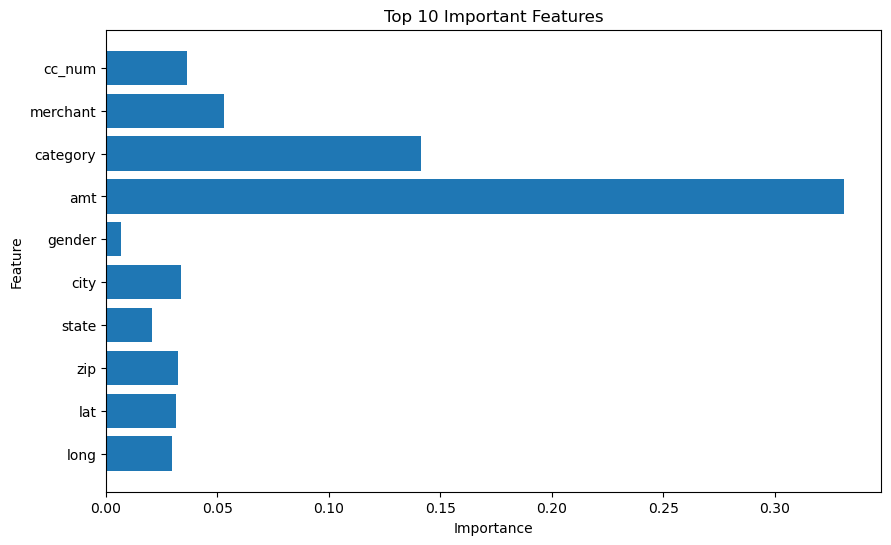

In [ ]:
#Helps to identify which transaction attribute is contributing most for the fraud
import matplotlib.pyplot as plt
importance = rf.feature_importances_
features = X.columns
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})
print(feature_importance.head(10))
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')
plt.show()

XG bosst used to improve accuracy


In [14]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
y_pred_xgb=xgb_model.predict(x_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb)*100)
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 99.91092636579573

Confusion Matrix:

[[110704     11]
 [    88    341]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.97      0.79      0.87       429

    accuracy                           1.00    111144
   macro avg       0.98      0.90      0.94    111144
weighted avg       1.00      1.00      1.00    111144

